Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test samples: 7178

==================== Evaluation Metrics ====================
Overall Accuracy:      0.7028
Macro F1 Score:        0.6869   <-- Recommended metric
Balanced Accuracy:     0.6851

Classification Report:

              precision    recall  f1-score   support

       angry       0.60      0.67      0.63       958
     disgust       0.71      0.65      0.68       111
        fear       0.57      0.51      0.54      1024
       happy       0.91      0.87      0.89      1774
     neutral       0.66      0.68      0.67      1233
         sad       0.59      0.59      0.59      1247
    surprise       0.81      0.82      0.81       831

    accuracy                           0.70      7178
   macro avg       0.69      0.69      0.69      7178
weighted avg       0.70      0.70      0.70      7178



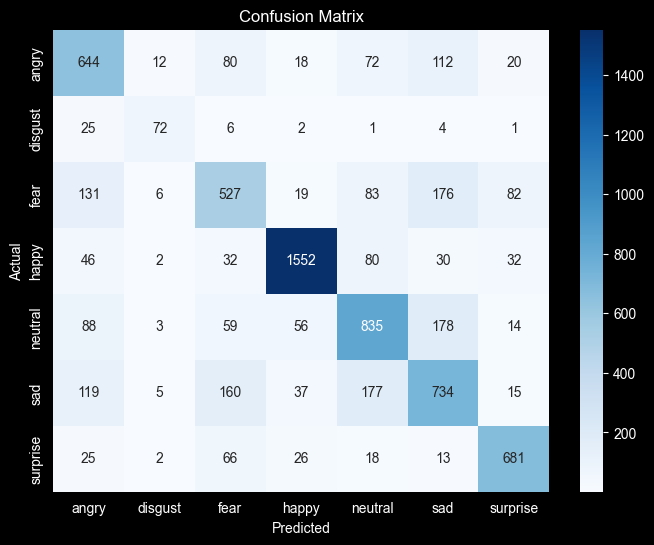


Per-Class Accuracy:
angry     : 0.6722
disgust   : 0.6486
fear      : 0.5146
happy     : 0.8749
neutral   : 0.6772
sad       : 0.5886
surprise  : 0.8195


In [1]:
# ======================================================
# Model Evaluation: Confusion Matrix + Detailed Metrics
# With Test Time Augmentation (TTA)
# ======================================================

import torch
import torch.nn as nn
import torchvision.models as models

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")


# ------------------------------------------------------
# Load trained model
# ------------------------------------------------------

model = models.efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 7)
)

model.load_state_dict(torch.load(
    "checkpoints/efficient_net_final_best.pth",
    map_location=device
))

model = model.to(device)
model.eval()


# ======================================================
# Create test dataset
# ======================================================

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(
    "../data/raw/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes

print("Classes:", class_names)
print("Test samples:", len(test_dataset))


# ======================================================
# Test Time Augmentation (TTA)
# Original + Flip + Slight Crops
# ======================================================

import torchvision.transforms.functional as TF

def predict_with_tta(model, images, device):

    model.eval()

    with torch.no_grad():

        images = images.to(device)

        # Original prediction
        out1 = torch.softmax(model(images), dim=1)

        # Horizontal flip
        flipped = torch.flip(images, dims=[3])
        out2 = torch.softmax(model(flipped), dim=1)

        # Slight crop (center crop 90%)
        crop = TF.center_crop(images, [int(images.shape[2]*0.9), int(images.shape[3]*0.9)])
        crop = torch.nn.functional.interpolate(crop, size=(224,224))
        out3 = torch.softmax(model(crop), dim=1)

        # Average predictions
        outputs = (out1 + out2 + out3) / 3

    return outputs


# ======================================================
# Run inference with TTA
# ======================================================

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        labels = labels.to(device)

        outputs = predict_with_tta(model, images, device)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ======================================================
# Overall Metrics
# ======================================================

overall_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n==================== Evaluation Metrics ====================")
print(f"Overall Accuracy:      {overall_accuracy:.4f}")
print(f"Macro F1 Score:        {macro_f1:.4f}   <-- Recommended metric")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")
print("=============================================================\n")


# ======================================================
# Classification Report
# ======================================================

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ======================================================
# Per-Class Accuracy
# ======================================================

print("\nPer-Class Accuracy:")

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls:10s}: {class_accuracy[i]:.4f}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test samples: 7178

==================== Evaluation Metrics ====================
Overall Accuracy:      0.6641
Macro F1 Score:        0.6417   <-- Recommended metric
Balanced Accuracy:     0.6334

Classification Report:

              precision    recall  f1-score   support

       angry       0.58      0.56      0.57       958
     disgust       0.73      0.55      0.63       111
        fear       0.53      0.40      0.46      1024
       happy       0.88      0.86      0.87      1774
     neutral       0.61      0.67      0.64      1233
         sad       0.52      0.60      0.55      1247
    surprise       0.75      0.80      0.78       831

    accuracy                           0.66      7178
   macro avg       0.66      0.63      0.64      7178
weighted avg       0.66      0.66      0.66      7178



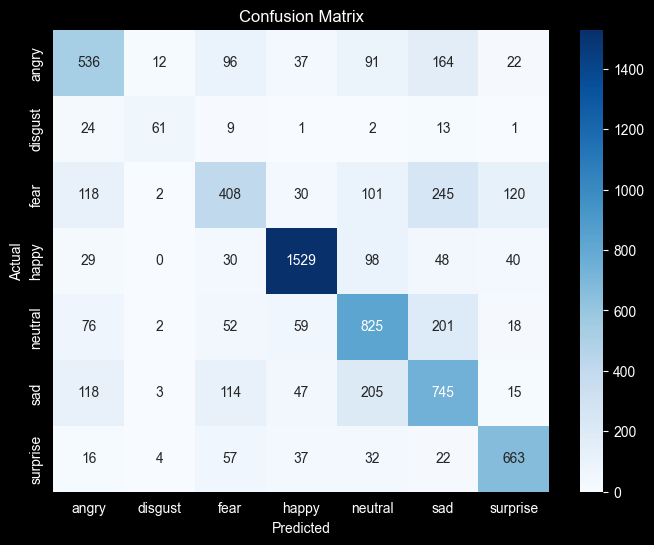


Per-Class Accuracy:
angry     : 0.5595
disgust   : 0.5495
fear      : 0.3984
happy     : 0.8619
neutral   : 0.6691
sad       : 0.5974
surprise  : 0.7978


In [2]:
# ======================================================
# Model Evaluation: Confusion Matrix + Detailed Metrics
# With Test Time Augmentation (TTA)
# ======================================================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ------------------------------------------------------
# Load trained model
# ------------------------------------------------------

model = models.mobilenet_v3_small(weights=None)

in_features = model.classifier[3].in_features

model.classifier[3] = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 7)
)

model.load_state_dict(torch.load(
    "checkpoints/mobilenet_v3_small_best_best.pth",
    map_location=device
))

model = model.to(device)
model.eval()


# ======================================================
# Create test dataset
# ======================================================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = datasets.ImageFolder(
    "../data/raw/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes

print("Classes:", class_names)
print("Test samples:", len(test_dataset))


# ======================================================
# Test Time Augmentation (TTA)
# Original + Flip + Slight Crops
# ======================================================

def predict_with_tta(model, images, device):

    model.eval()

    with torch.no_grad():

        images = images.to(device)

        # Original prediction
        out1 = torch.softmax(model(images), dim=1)

        # Horizontal flip
        flipped = torch.flip(images, dims=[3])
        out2 = torch.softmax(model(flipped), dim=1)

        # Slight crop (center crop 90%)
        crop = TF.center_crop(images, [int(images.shape[2]*0.9), int(images.shape[3]*0.9)])
        crop = torch.nn.functional.interpolate(crop, size=(224,224))
        out3 = torch.softmax(model(crop), dim=1)

        # Average predictions
        outputs = (out1 + out2 + out3) / 3

    return outputs


# ======================================================
# Run inference with TTA
# ======================================================

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        labels = labels.to(device)

        outputs = predict_with_tta(model, images, device)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ======================================================
# Overall Metrics
# ======================================================

overall_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n==================== Evaluation Metrics ====================")
print(f"Overall Accuracy:      {overall_accuracy:.4f}")
print(f"Macro F1 Score:        {macro_f1:.4f}   <-- Recommended metric")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")
print("=============================================================\n")


# ======================================================
# Classification Report
# ======================================================

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ======================================================
# Per-Class Accuracy
# ======================================================

print("\nPer-Class Accuracy:")

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls:10s}: {class_accuracy[i]:.4f}")

/Users/bsama/Desktop/Github emotion recognition/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test samples: 7178

==================== Evaluation Metrics ====================
Overall Accuracy:      0.6785
Macro F1 Score:        0.6627   <-- Recommended metric
Balanced Accuracy:     0.6598

Classification Report:

              precision    recall  f1-score   support

       angry       0.62      0.56      0.59       958
     disgust       0.68      0.64      0.66       111
        fear       0.53      0.50      0.51      1024
       happy       0.87      0.87      0.87      1774
     neutral       0.62      0.67      0.65      1233
         sad       0.55      0.57      0.56      1247
    surprise       0.79      0.81      0.80       831

    accuracy                           0.68      7178
   macro avg       0.67      0.66      0.66      7178
weighted avg       0.68      0.68      0.68      7178



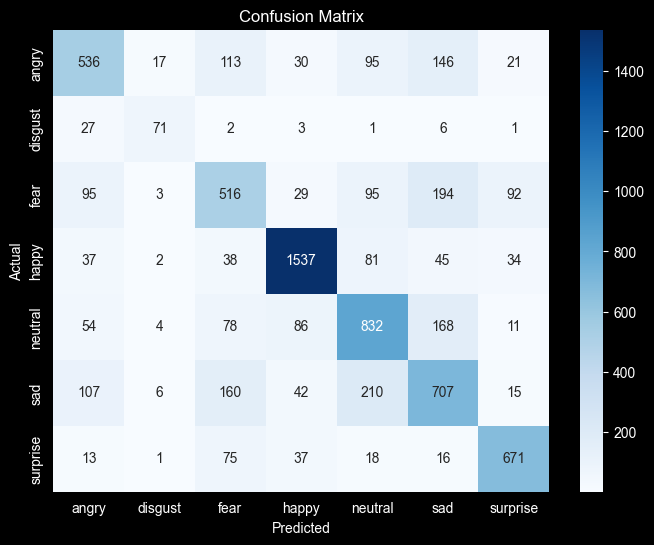


Per-Class Accuracy:
angry     : 0.5595
disgust   : 0.6396
fear      : 0.5039
happy     : 0.8664
neutral   : 0.6748
sad       : 0.5670
surprise  : 0.8075


In [3]:
# ======================================================
# Model Evaluation: Confusion Matrix + Detailed Metrics
# With Test Time Augmentation (TTA)
# ======================================================

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# ------------------------------------------------------
# Load trained model
# ------------------------------------------------------

import timm

model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=False,
    num_classes=7
)

model.load_state_dict(torch.load(
    "checkpoints/vit_small_best_best.pth",
    map_location=device
))

model = model.to(device)
model.eval()

# ======================================================
# Create test dataset
# ======================================================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

test_dataset = datasets.ImageFolder(
    "../data/raw/test",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes

print("Classes:", class_names)
print("Test samples:", len(test_dataset))


# ======================================================
# Test Time Augmentation (TTA)
# Original + Flip + Slight Crops
# ======================================================

import torchvision.transforms.functional as TF

def predict_with_tta(model, images, device):

    model.eval()

    with torch.no_grad():

        images = images.to(device)

        # Original prediction
        out1 = torch.softmax(model(images), dim=1)

        # Horizontal flip
        flipped = torch.flip(images, dims=[3])
        out2 = torch.softmax(model(flipped), dim=1)

        # Slight crop (center crop 90%)
        crop = TF.center_crop(images, [int(images.shape[2]*0.9), int(images.shape[3]*0.9)])
        crop = torch.nn.functional.interpolate(crop, size=(224,224))
        out3 = torch.softmax(model(crop), dim=1)

        # Average predictions
        outputs = (out1 + out2 + out3) / 3

    return outputs


# ======================================================
# Run inference with TTA
# ======================================================

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        labels = labels.to(device)

        outputs = predict_with_tta(model, images, device)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# ======================================================
# Overall Metrics
# ======================================================

overall_accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average="macro")
balanced_acc = balanced_accuracy_score(all_labels, all_preds)

print("\n==================== Evaluation Metrics ====================")
print(f"Overall Accuracy:      {overall_accuracy:.4f}")
print(f"Macro F1 Score:        {macro_f1:.4f}   <-- Recommended metric")
print(f"Balanced Accuracy:     {balanced_acc:.4f}")
print("=============================================================\n")


# ======================================================
# Classification Report
# ======================================================

print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))


# ======================================================
# Confusion Matrix
# ======================================================

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# ======================================================
# Per-Class Accuracy
# ======================================================

print("\nPer-Class Accuracy:")

class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, cls in enumerate(class_names):
    print(f"{cls:10s}: {class_accuracy[i]:.4f}")